# TASK 1: Data gathering and exploratory analysis

# Step 1: IMPORT LIBRARIES AND DATASETS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
# loading the dataset
demographics = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Customer_Demographics")
transactions = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Transaction_History")
service = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Customer_Service")
activity = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Online_Activity")
churn = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Churn_Status")

In [4]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [5]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [6]:
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [7]:
activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [8]:
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


# Step 2: Merge the Tables

### All tables have CustomerID, so we combine them.

In [9]:
df = demographics.merge(activity, on="CustomerID")
df = df.merge(churn, on="CustomerID")

### For transactions and service we usually aggregate because customers have multiple records.

In [10]:
transactions_summary = transactions.groupby("CustomerID")["AmountSpent"].sum().reset_index()

df = df.merge(transactions_summary, on="CustomerID")

# Step 3: Exploratory Data Analysis

In [11]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,AmountSpent
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,0,416.50
1,2,65,M,Married,Low,2023-12-05,5,Website,1,1547.42
2,3,18,M,Single,Low,2023-11-15,3,Website,0,1702.98
3,4,21,M,Widowed,Low,2023-08-25,2,Website,0,917.29
4,5,21,M,Divorced,Medium,2023-10-27,41,Website,0,2001.49


In [12]:
df.tail()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,AmountSpent
995,996,54,F,Single,Low,2023-01-29,38,Mobile App,0,227.25
996,997,19,M,Widowed,High,2023-04-01,5,Mobile App,0,419.82
997,998,47,M,Married,Low,2023-07-10,47,Website,0,252.15
998,999,23,M,Widowed,High,2023-01-08,23,Website,0,2393.26
999,1000,34,M,Widowed,Low,2023-08-13,22,Mobile App,0,1670.79


In [13]:
df.shape

(1000, 10)

In [14]:
df.describe()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,AmountSpent
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,2023-07-05 21:28:48,25.912000,0.204000,1267.074950
min,1.000000,18.000000,2023-01-01 00:00:00,1.000000,0.000000,9.800000
25%,250.750000,30.000000,2023-04-08 00:00:00,13.750000,0.000000,626.685000
50%,500.500000,43.000000,2023-07-10 12:00:00,27.000000,0.000000,1232.880000
75%,750.250000,56.000000,2023-10-01 06:00:00,38.000000,0.000000,1791.902500
max,1000.000000,69.000000,2023-12-31 00:00:00,49.000000,1.000000,3386.040000
std,288.819436,15.242311,NaN,14.055953,0.403171,738.590013


### Histogram (Age Distribution)

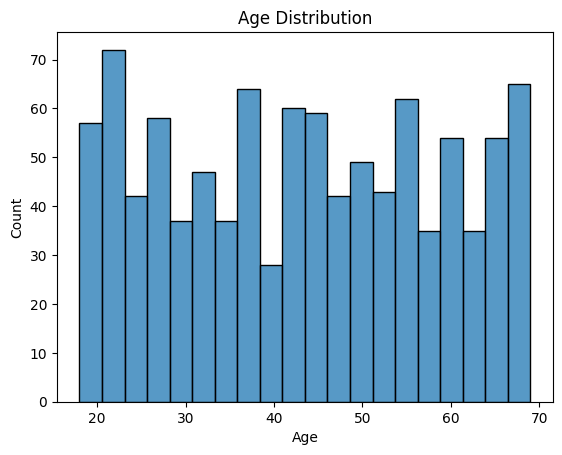

In [15]:
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

### Boxplot (Outliers)

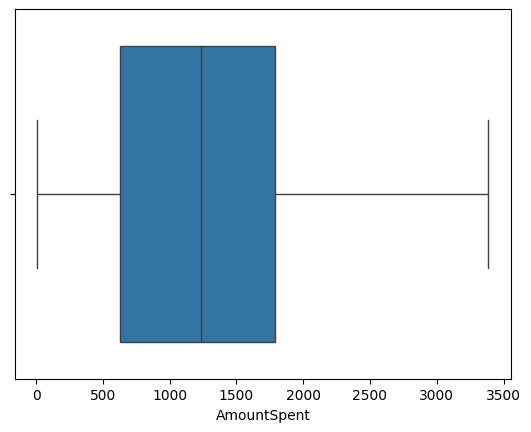

In [16]:
sns.boxplot(x=df["AmountSpent"])
plt.show()

### Customers with low login frequency show higher churn probability.

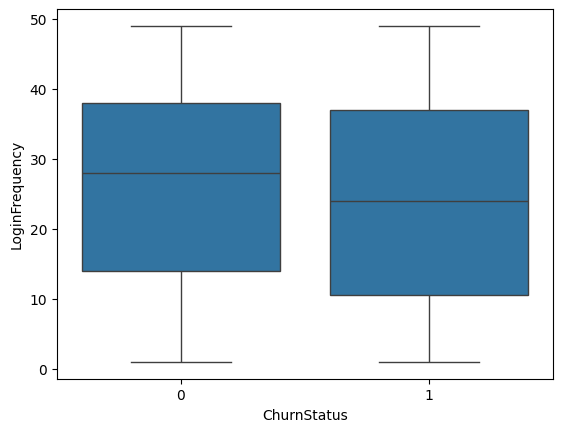

In [17]:
sns.boxplot(x="ChurnStatus", y="LoginFrequency", data=df)
plt.show()

### Correlation Heatmap

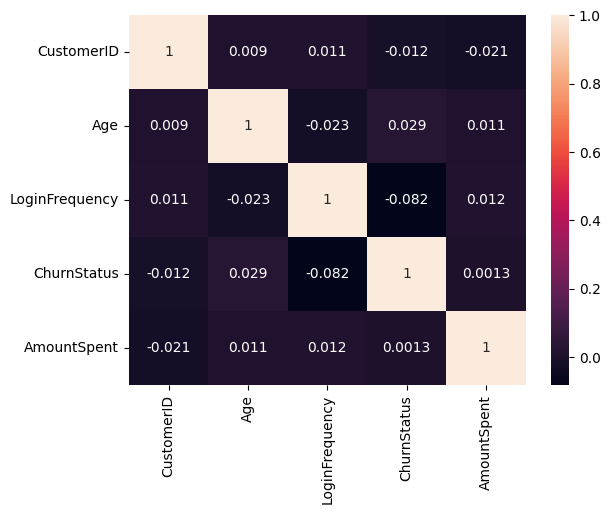

In [18]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

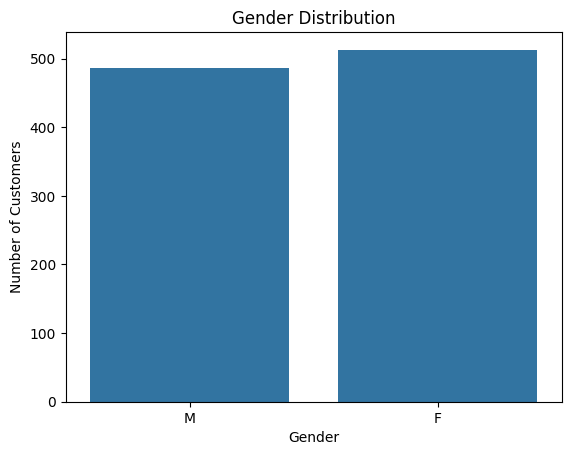

In [19]:
sns.countplot(x="Gender", data=demographics)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

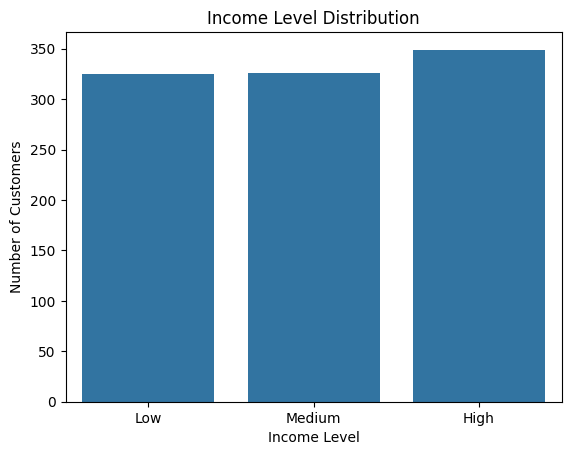

In [20]:
sns.countplot(x="IncomeLevel", data=demographics)
plt.title("Income Level Distribution")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.show()

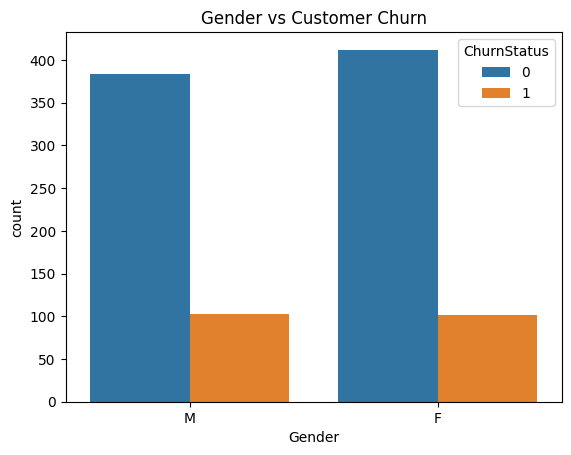

In [21]:
sns.countplot(x="Gender", hue="ChurnStatus", data=df)
plt.title("Gender vs Customer Churn")
plt.show()

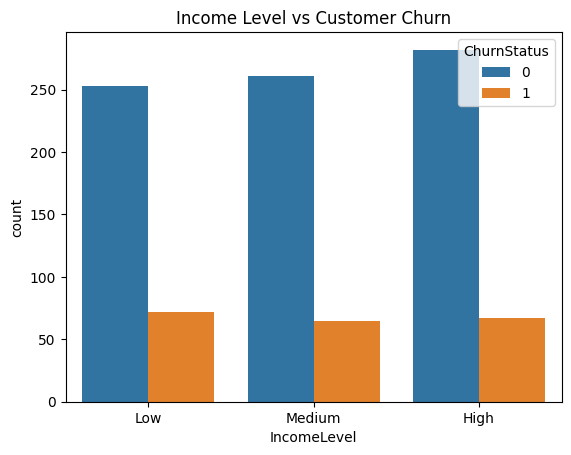

In [22]:
sns.countplot(x="IncomeLevel", hue="ChurnStatus", data=df)
plt.title("Income Level vs Customer Churn")
plt.show()

# Step 4: Data Cleaning

In [23]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
MaritalStatus     0
IncomeLevel       0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
ChurnStatus       0
AmountSpent       0
dtype: int64

### There are no missing values in this data set

# Step 5: Encode Categorical Variables

In [24]:
df = pd.get_dummies(df, drop_first=True)

# Step 6: Standardization

In [25]:
scaler = StandardScaler()

df["Age"] = scaler.fit_transform(df[["Age"]])
df["AmountSpent"] = scaler.fit_transform(df[["AmountSpent"]])

# Step 7: Now Dataset is Ready For Machine Learning Models

In [26]:
df.head()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,AmountSpent,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.229628,2023-10-21,34,0,-1.152196,True,False,True,False,True,False,False,False
1,2,1.426547,2023-12-05,5,1,0.379758,True,True,False,False,True,False,False,True
2,3,-1.658518,2023-11-15,3,0,0.590481,True,False,True,False,True,False,False,True
3,4,-1.461599,2023-08-25,2,0,-0.473822,True,False,False,True,True,False,False,True
4,5,-1.461599,2023-10-27,41,0,0.994845,True,False,False,False,False,True,False,True
